In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Resolve project root regardless of how the notebook is launched
_here = Path().resolve()
PROJECT_ROOT = _here.parent if _here.name == 'notebooks' else _here
os.chdir(PROJECT_ROOT)

SCREENSHOT_DIR = PROJECT_ROOT / 'screenshots' / 'eda'
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
TARGET_PALETTE = ['#2196F3', '#F44336']
TARGET = 'num'

print('Project root  :', PROJECT_ROOT)
print('Screenshots   :', SCREENSHOT_DIR)

Project root  : C:\gmr\projects\mtech_mlops_assignment_01
Screenshots   : C:\gmr\projects\mtech_mlops_assignment_01\screenshots\eda


## Section 1 — Dataset Overview

In [2]:
df_raw = pd.read_csv('data/raw/heart_disease_raw.csv')
df     = pd.read_csv('data/processed/heart_disease_clean.csv')

print('=== Raw Dataset ===')
print('Shape   :', df_raw.shape)
print('Columns :', list(df_raw.columns))
print()
print('Data types:')
print(df_raw.dtypes.to_string())

=== Raw Dataset ===
Shape   : (303, 14)
Columns : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64


In [3]:
print('=== Processed Dataset — Descriptive Statistics ===')
df.describe().round(2)

=== Processed Dataset — Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.66,4.72,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


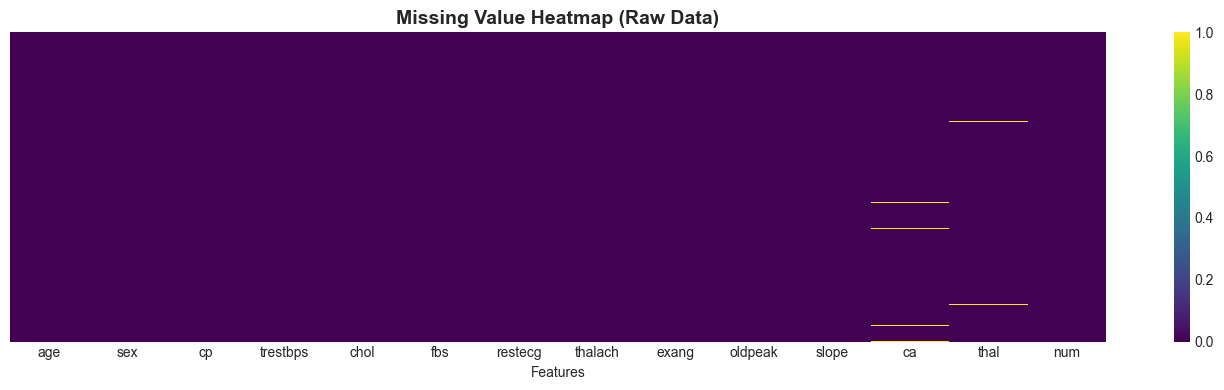

Missing value counts:
ca      4
thal    2
dtype: int64


In [4]:
df_check = df_raw.replace('?', float('nan'))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df_check.isnull(),
    yticklabels=False,
    cbar=True,
    cmap='viridis',
    ax=ax
)
ax.set_title('Missing Value Heatmap (Raw Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '01_missing_value_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

missing = df_check.isnull().sum()
missing_cols = missing[missing > 0]
if missing_cols.empty:
    print('No missing values — dataset is complete.')
else:
    print('Missing value counts:')
    print(missing_cols)

## Section 2 — Feature Distributions

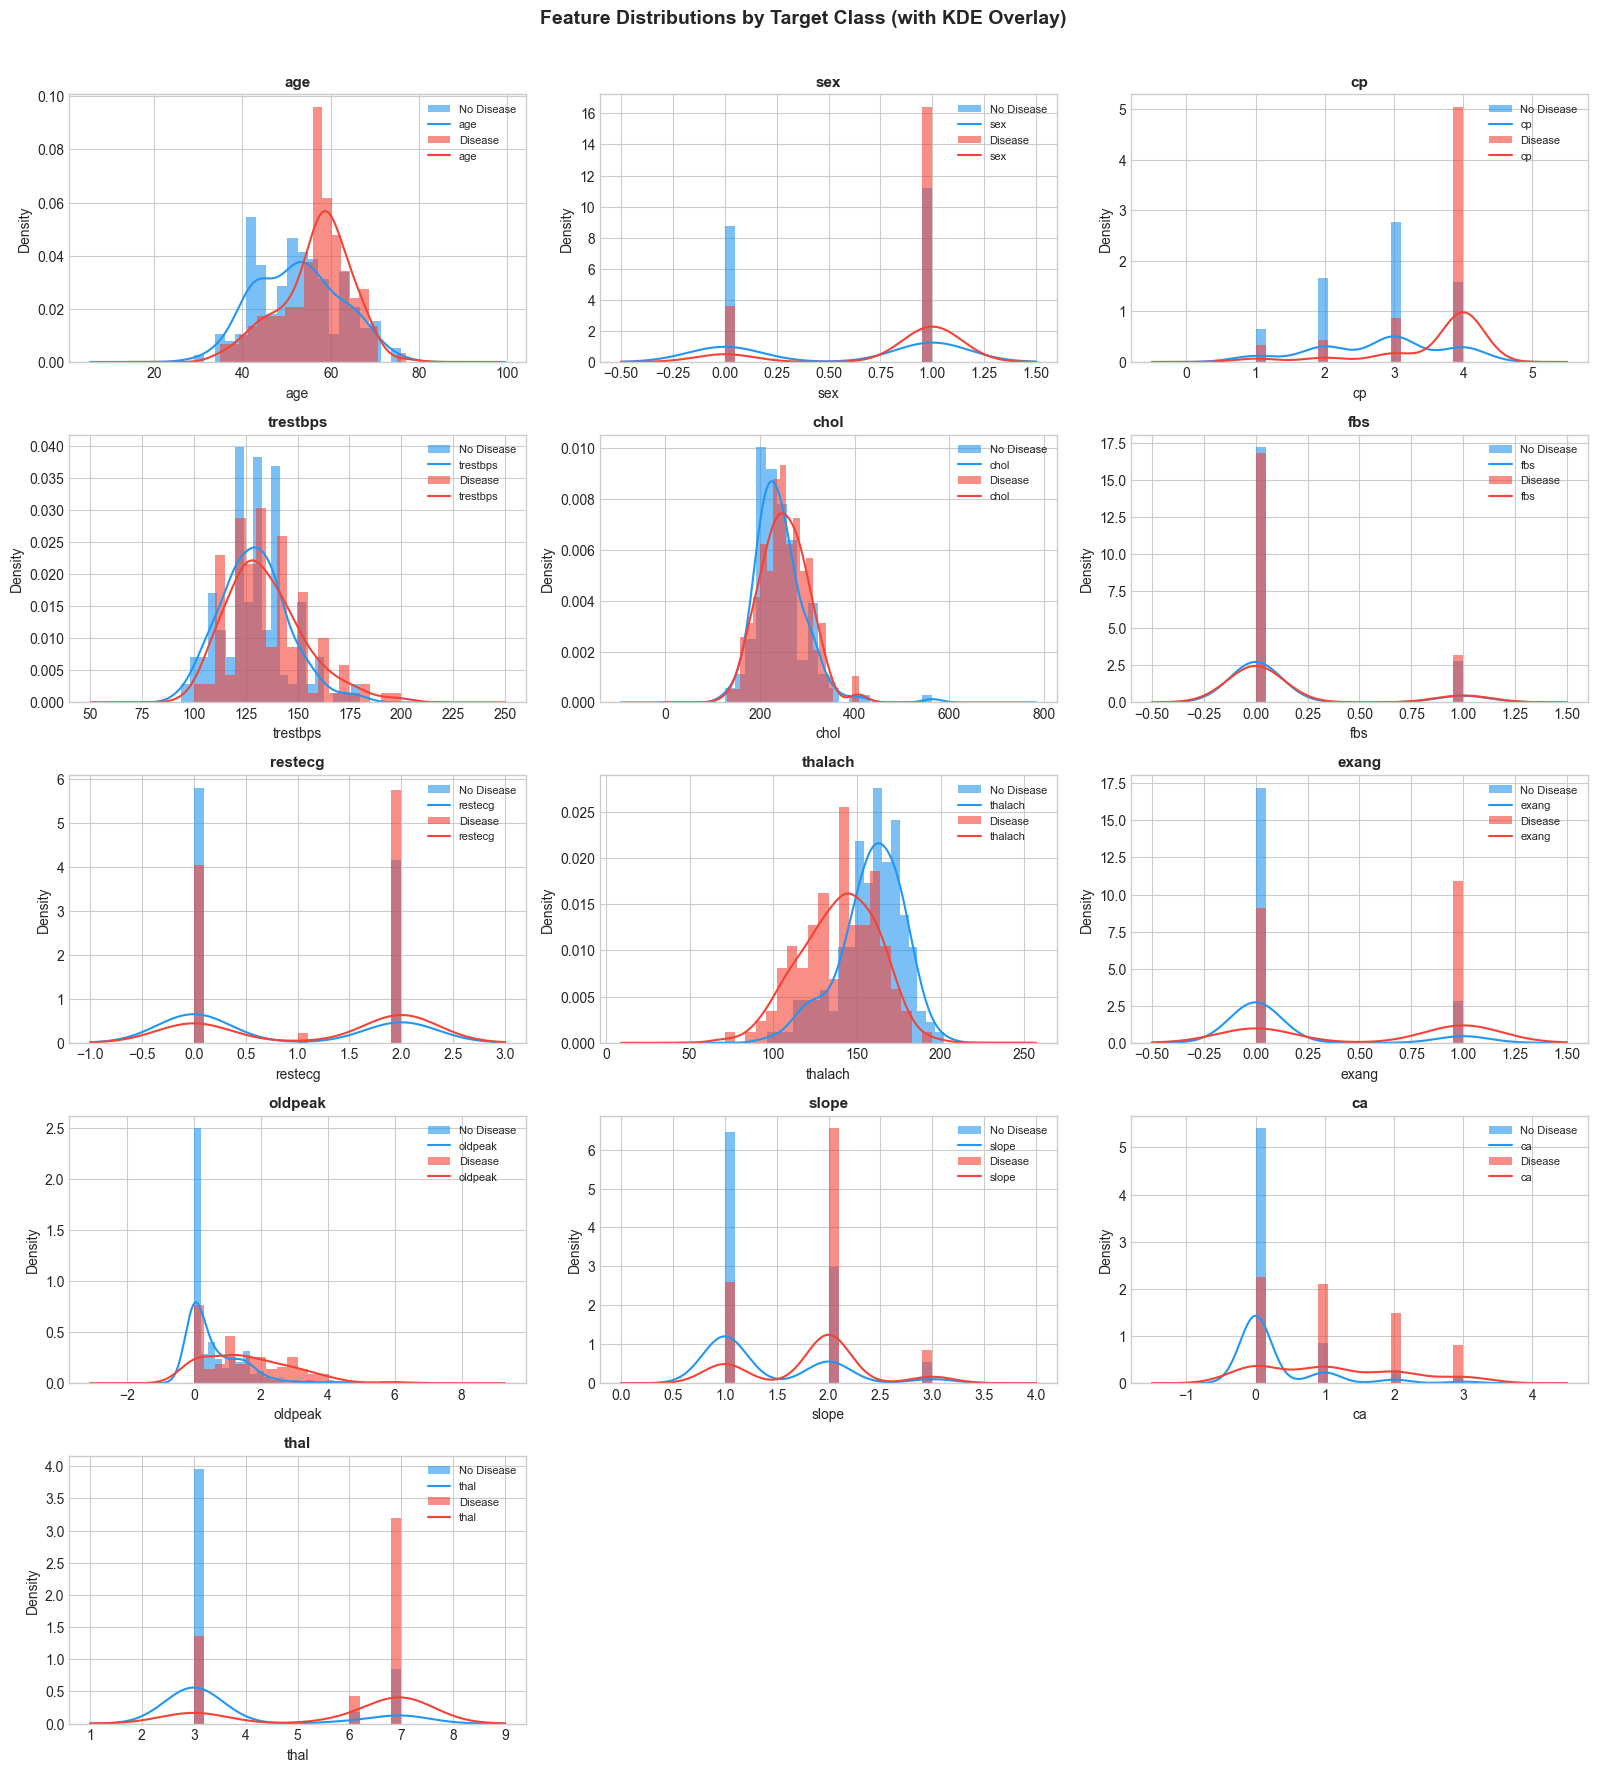

In [5]:
FEATURE_COLS = [c for c in df.columns if c != TARGET]
n_cols = 3
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for cls, color, label in zip([0, 1], TARGET_PALETTE, ['No Disease', 'Disease']):
        subset = df[df[TARGET] == cls][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, density=True)
        try:
            subset.plot.kde(ax=ax, color=color, linewidth=1.5)
        except Exception:
            pass
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Feature Distributions by Target Class (with KDE Overlay)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Class Balance

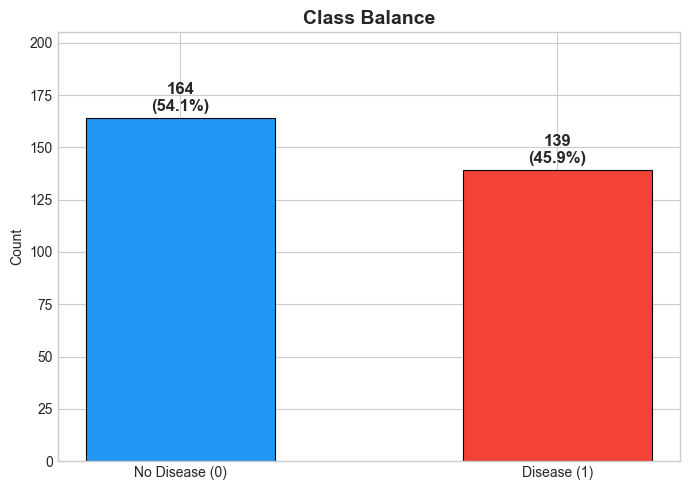

Class 0 (no disease): 164 samples (54.1%)
Class 1 (disease)   : 139 samples (45.9%)
Imbalance ratio     : 1.18:1
Assessment: Approximately balanced — no resampling strictly required.


In [6]:
counts = df[TARGET].value_counts().sort_index()
total  = len(df)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['No Disease (0)', 'Disease (1)'],
    counts.values,
    color=TARGET_PALETTE,
    edgecolor='black',
    linewidth=0.8,
    width=0.5
)
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
ax.set_title('Class Balance', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.25)
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '03_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts.max() / counts.min()
print(f'Class 0 (no disease): {counts[0]} samples ({counts[0] / total * 100:.1f}%)')
print(f'Class 1 (disease)   : {counts[1]} samples ({counts[1] / total * 100:.1f}%)')
print(f'Imbalance ratio     : {ratio:.2f}:1')
if ratio < 1.5:
    print('Assessment: Approximately balanced — no resampling strictly required.')
else:
    print('Assessment: Mild imbalance — consider class_weight=balanced or SMOTE.')

## Section 4 — Correlation Analysis

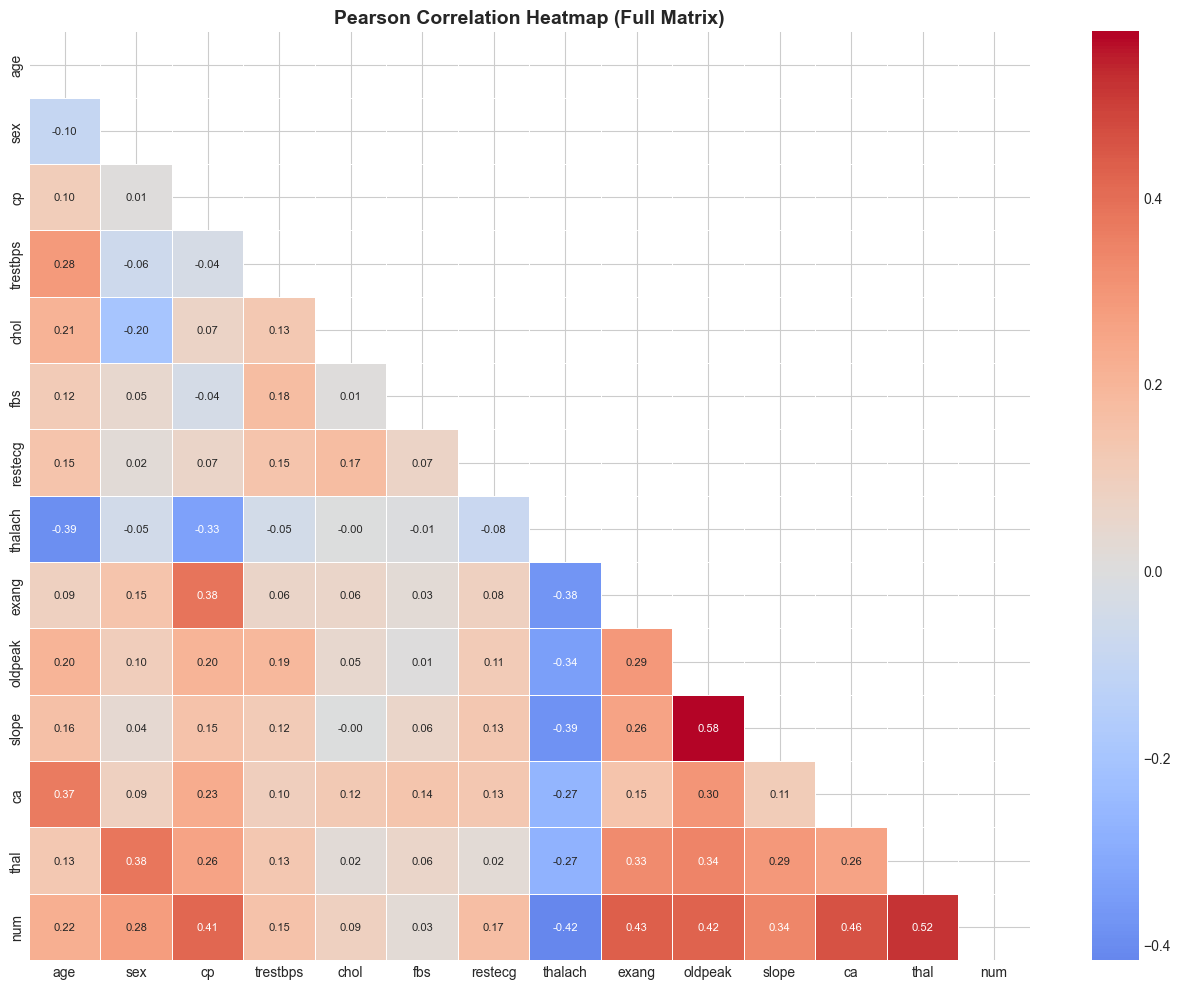

Top 5 features most correlated with target:
thal       0.522057
ca         0.460033
exang      0.431894
oldpeak    0.424510
thalach    0.417167


In [7]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Heatmap (Full Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Top 5 features most correlated with target:')
print(target_corr.head(5).to_string())
TOP_FEATURES = target_corr.head(6).index.tolist()

## Section 5 — Feature Relationships

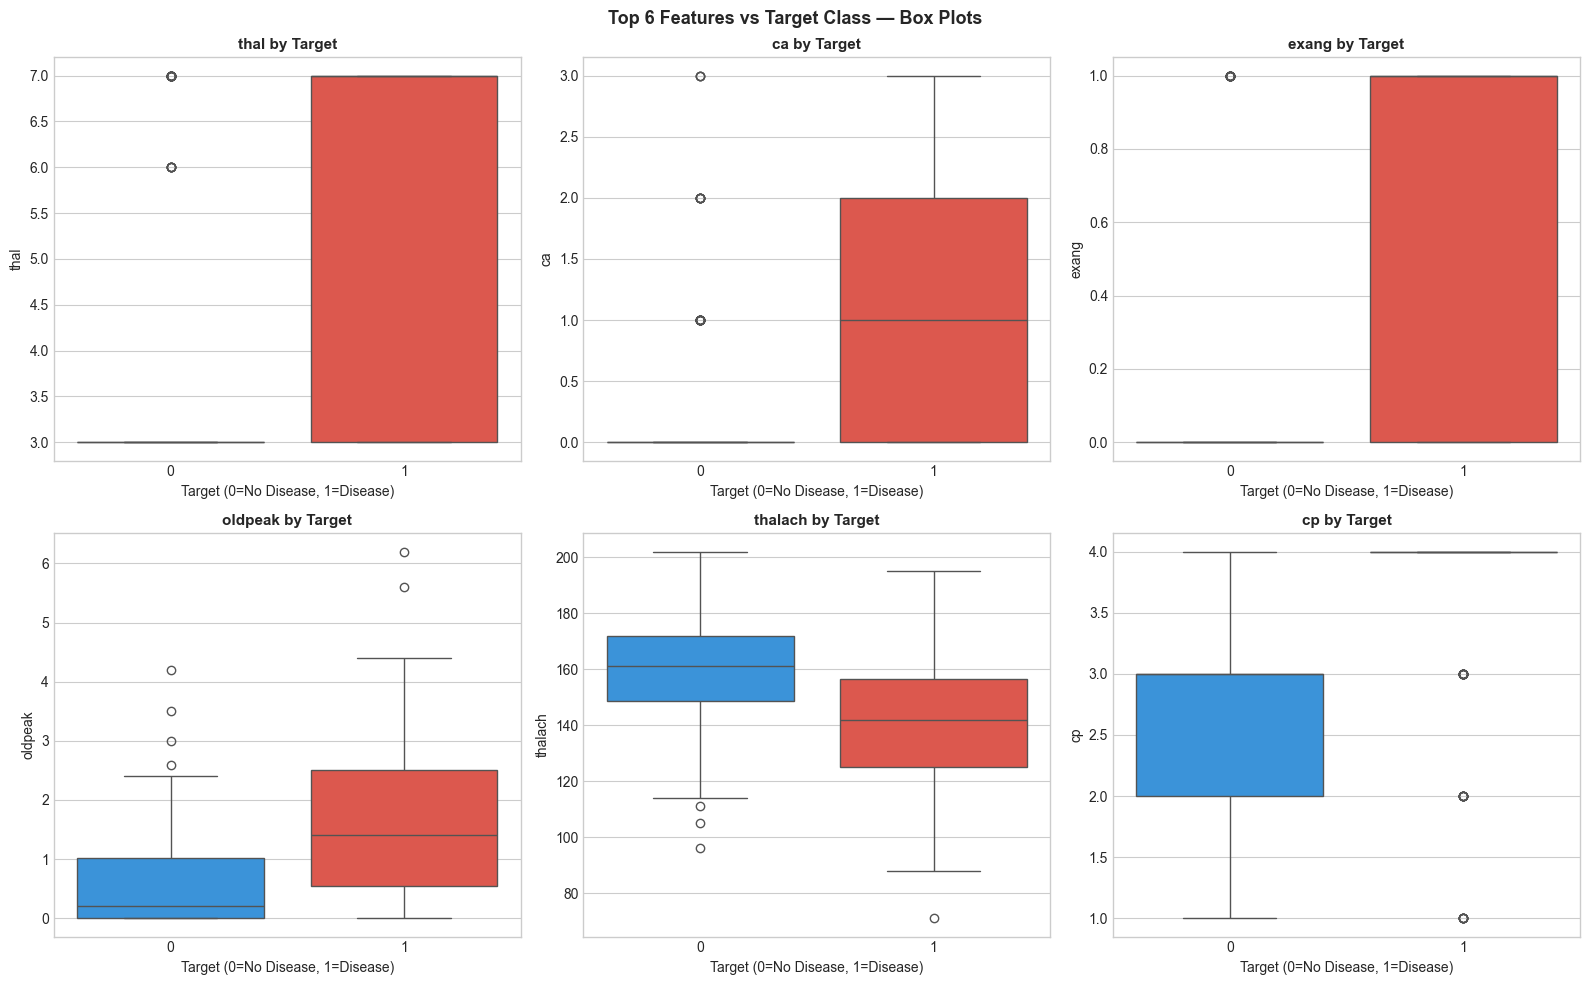

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(TOP_FEATURES):
    sns.boxplot(
        data=df, x=TARGET, y=feat,
        palette=TARGET_PALETTE, ax=axes[i]
    )
    axes[i].set_title(f'{feat} by Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')

fig.suptitle('Top 6 Features vs Target Class — Box Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '05_boxplots_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

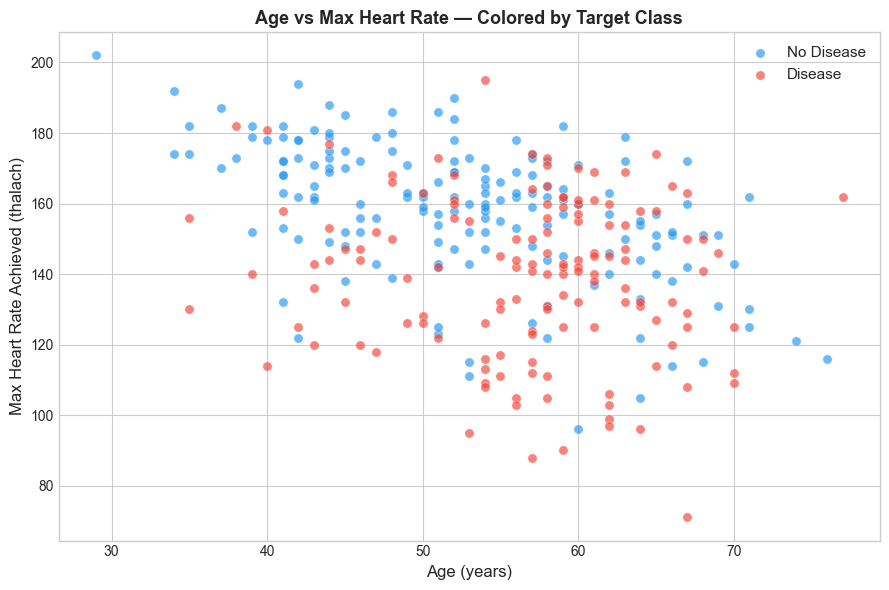

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for cls, color, label in zip([0, 1], TARGET_PALETTE, ['No Disease', 'Disease']):
    s = df[df[TARGET] == cls]
    ax.scatter(
        s['age'], s['thalach'],
        c=color, label=label, alpha=0.65, s=45,
        edgecolors='white', linewidth=0.4
    )
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Max Heart Rate Achieved (thalach)', fontsize=12)
ax.set_title('Age vs Max Heart Rate — Colored by Target Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '06_scatter_age_thalach.png', dpi=150, bbox_inches='tight')
plt.show()

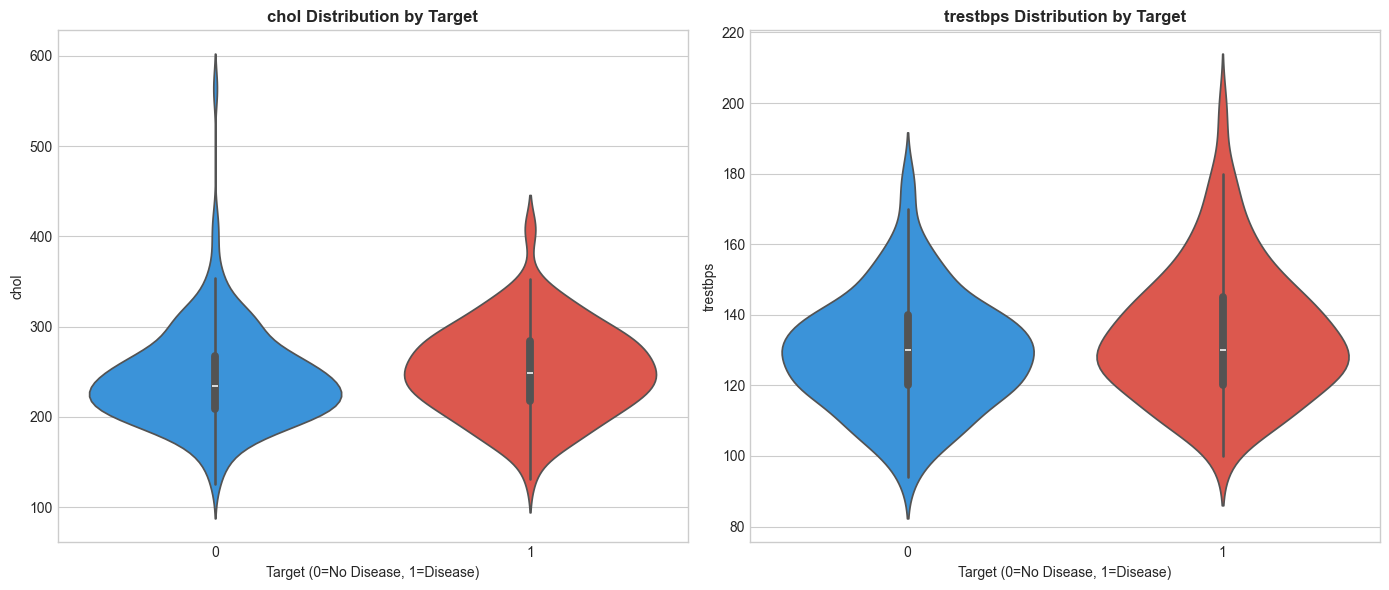

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, feat in zip(axes, ['chol', 'trestbps']):
    sns.violinplot(
        data=df, x=TARGET, y=feat,
        palette=TARGET_PALETTE, ax=ax, inner='box'
    )
    ax.set_title(f'{feat} Distribution by Target', fontsize=12, fontweight='bold')
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')
plt.tight_layout()
plt.savefig(SCREENSHOT_DIR / '07_violin_chol_trestbps.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — EDA Summary

### Key Findings

- **Class balance**: ~54% No Disease / ~46% Disease — approximately balanced; no resampling
  strictly required, but `class_weight='balanced'` is a low-cost safeguard for margin-based models.
- **Top predictive features** (Pearson |r| with target): `thalach`, `ca`, `oldpeak`, `cp`, `exang`
  — all clinically meaningful indicators.
- **thalach (max heart rate)**: Lower values strongly associated with disease presence.
  Clear separation visible in histograms and box plots.
- **oldpeak (ST depression)**: Right-skewed; higher values correlate strongly with disease.
  One outlier near 6.2 is a plausible clinical extreme — retained.
- **cp (chest pain type)**: Ordinal/nominal — `OneHotEncoder` is appropriate;
  shows the clearest visual class separation.
- **ca & thal**: Both have a small number of missing values (2–7 rows);
  imputed with mode (categorical strategy).
- **chol**: Extreme values (> 500 mg/dl) visible in violin plot — these represent
  real clinical presentations, not data errors; retained.
- **Age vs thalach scatter**: Disease patients cluster upper-left (older age, lower max HR),
  confirming both features carry complementary signal.

### Feature Engineering Decisions

1. **StandardScaler** on continuous numerics: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`.
2. **OneHotEncoder** (`handle_unknown='ignore'`) on categoricals:
   `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`.
3. Both transformers wrapped in a `ColumnTransformer` inside a sklearn `Pipeline` —
   ensures identical preprocessing is applied at inference time (no train/serve skew).
4. No dimensionality reduction needed: 13 features × 303 samples is comfortably within
   a linear regime and tree models handle this scale natively.